<a href="https://colab.research.google.com/github/leobernardi1999/2025_Intro_Python/blob/main/FEEDBACK_LEONARDO_BERNARDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (Exercise) Ocean Floats Data Analysis

**Learning Objectives**

*    Creating new arrays using `linspace` and `arange`
*    Computing basic formulas with `numpy` arrays
*    Loading data from `.npy` files
*    Performing reductions (e.g. `mean`, `std` on `numpy` arrays)
*    Making 1D line plots
*    Making scatterplots
*    Annotating plots with titles and axes

In this problem, we use real data from ocean profiling floats. [ARGO](http://www.argo.ucsd.edu/) floats are autonomous robotic instruments that collect Temperature, Salinity, and Pressure data from the ocean. [ARGO](http://www.argo.ucsd.edu/) floats collect one “profile” (a set of messurements at different depths or “levels”).

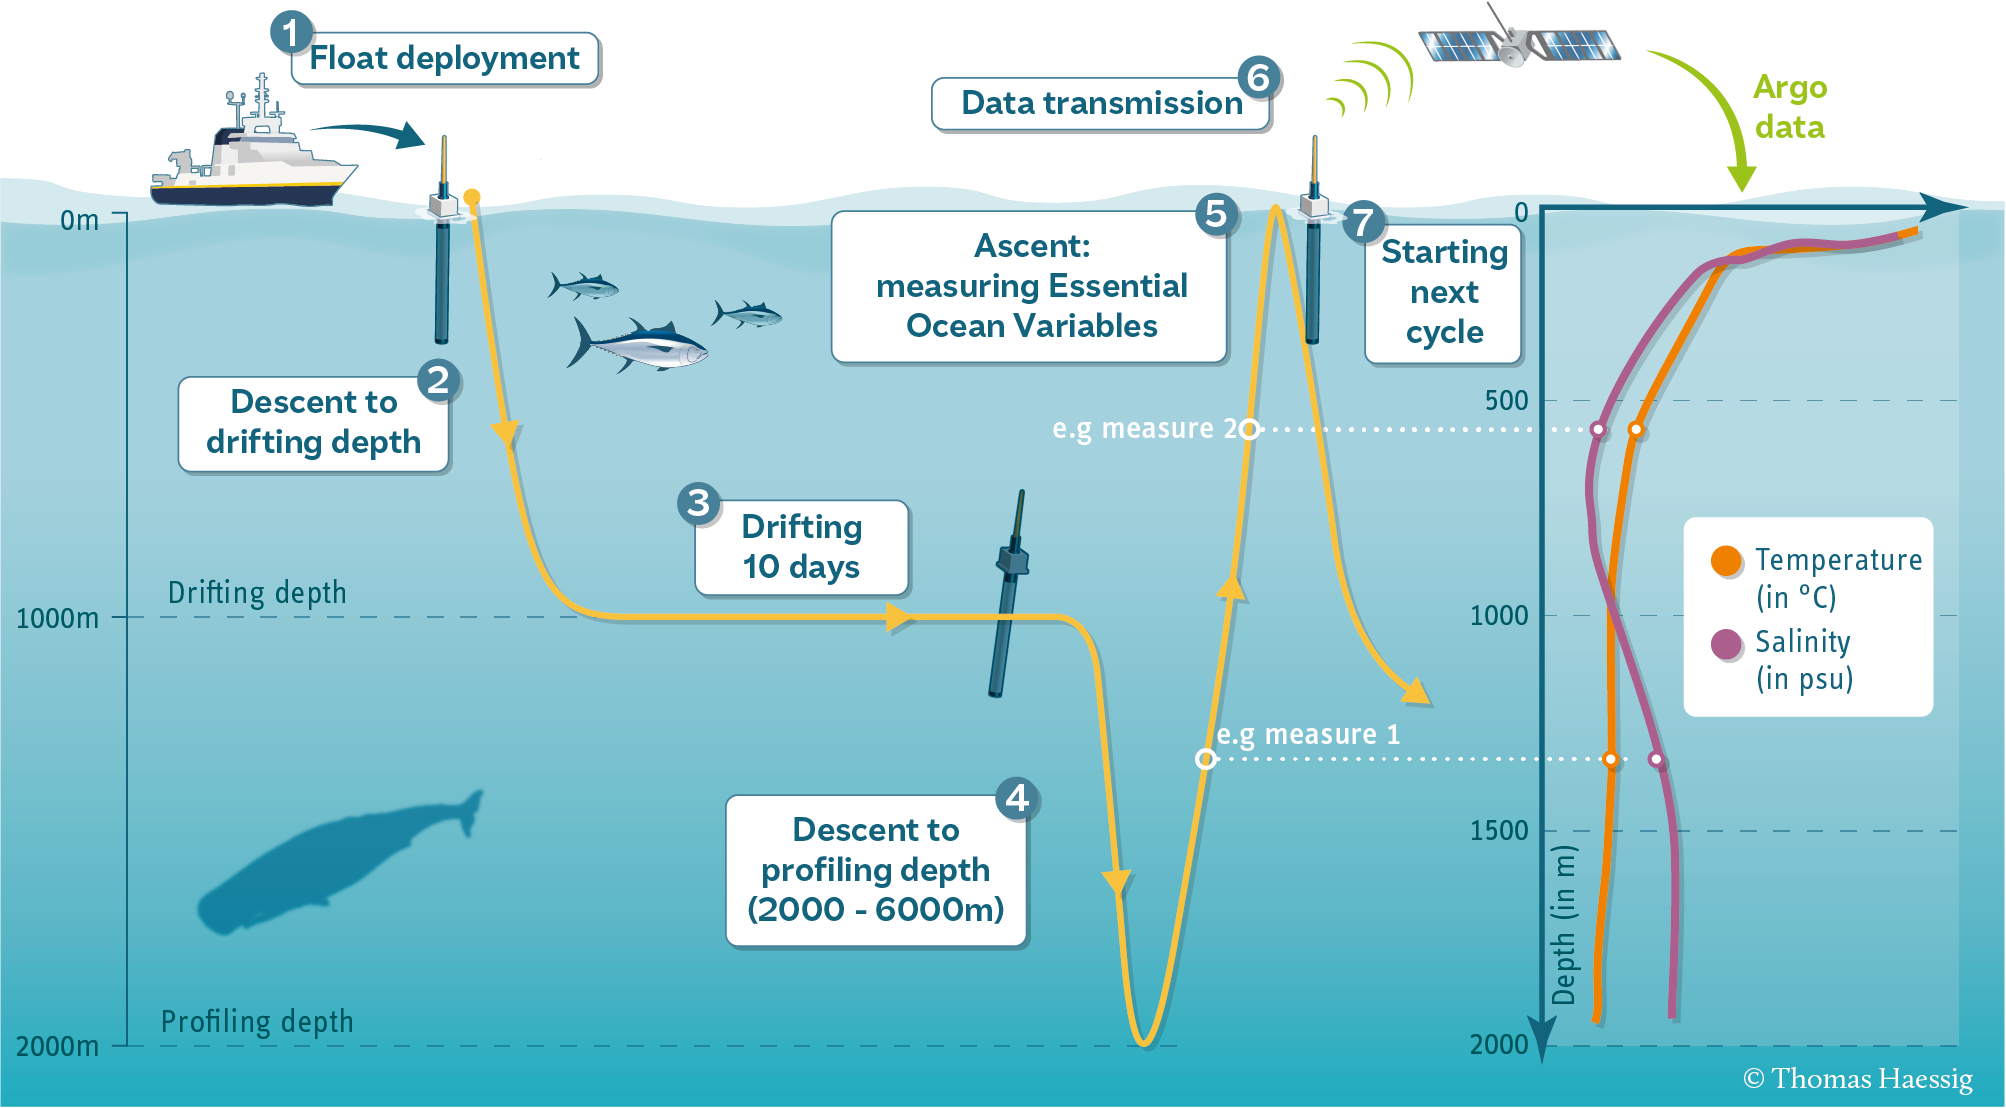


Each profile has a single latitude, longitude, and date associated with it, in addition to many different levels.

Let’s start by using [pooch](https://www.fatiando.org/pooch/latest/) to download the data files we need for this exercise. The following code will give you a list of `.npy` files that you can open in the next step.

In [162]:
import pooch

url = "https://unils-my.sharepoint.com/:u:/g/personal/tom_beucler_unil_ch/EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ?download=1"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash='2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009')
files

['/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/levels.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lat.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/T.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/date.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lon.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/P.npy',
 '/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/S.npy']

In [163]:
import numpy as np

**Q1) Load each data file as a `numpy` array.**

You can use whatever names you want for your arrays, but we recommend:

`T`: temperature

`S`: salinity

`P`: pressure

`date`: date

`lat`: latitude

`lon`: longitude

`level`: depth level

Hint 1: Look at the file name (the items in `files`) to know which files corresponds to which variable.

Hint 2: Check out the documentation for [`np.load`](https://numpy.org/doc/stable/reference/generated/numpy.load.html).

Display the names of the items in files here

In [164]:
date=np.load('/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/date.npy')
lat=np.load('/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lat.npy')
T=np.load('/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/T.npy')
S=np.load('/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/S.npy')
lon=np.load('/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/lon.npy')
level=np.load('/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/levels.npy')
P=np.load('/root/.cache/pooch/4e2111f8c8dc35a2e2c0f9ec759ecb61-EZwbaBqass1LhZO3DS3BCL0BhIlcENuoDItMB9b4IYDUCQ.unzip/float_data/P.npy')







Then, load the files as `numpy` arrays, for instance using list comprehension

In [165]:
T,lat,S,level,lon,P,date = [np.load(files[i]) for i in range(len(files))]

**Q2) Recreate the `level` array using `np.arange` and `np.linspace`**

Hints:

*   The documentation for `np.arange` is [at this link](https://numpy.org/devdocs/reference/generated/numpy.arange.html)
*   The documentation for `np.linspace` is [at this link](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)
*   The documentation for `np.testing.assert_equal` is [at this link](https://numpy.org/doc/stable/reference/generated/numpy.testing.assert_equal.html)

Display the `level` array

In [166]:
print(level)

['2012-07-13T22:33:06.019200000' '2012-07-23T22:54:59.990400000'
 '2012-08-02T22:55:52.003200000' '2012-08-12T23:08:59.971200000'
 '2012-08-22T23:29:01.968000000' '2012-09-01T23:17:38.976000000'
 '2012-09-12T02:59:18.960000000' '2012-09-21T23:18:37.036800000'
 '2012-10-02T03:00:17.971200000' '2012-10-11T23:13:27.984000000'
 '2012-10-22T02:50:32.006400000' '2012-10-31T23:36:39.974400000'
 '2012-11-11T02:40:46.041600000' '2012-11-20T23:08:29.990400000'
 '2012-12-01T02:47:51.993600000' '2012-12-10T23:23:16.972800000'
 '2012-12-21T02:58:48.979200000' '2012-12-30T23:07:23.030400000'
 '2013-01-10T02:56:43.008000000' '2013-01-19T23:24:26.956800000'
 '2013-01-30T02:43:53.011200000' '2013-02-08T23:15:27.043200000'
 '2013-02-19T01:12:50.976000000' '2013-02-28T23:07:13.008000000'
 '2013-03-11T02:43:30.979200000' '2013-03-20T23:17:22.992000000'
 '2013-03-31T01:50:38.025600000' '2013-04-09T23:19:07.968000000'
 '2013-04-20T02:53:29.990400000' '2013-04-29T23:28:33.024000000'
 '2013-05-10T02:50:18.009

Recreate the `level` array using `np.arange` and call it `level_arange`

In [167]:
level_arange = np.arange(0,78)



Check that `level` and `level_arange` are equal using `np.testing.assert_equal`

In [168]:
np.testing.assert_equal(level,level_arange)

AssertionError: 
Arrays are not equal

(shapes (75,), (78,) mismatch)
 ACTUAL: array(['2012-07-13T22:33:06.019200000', '2012-07-23T22:54:59.990400000',
       '2012-08-02T22:55:52.003200000', '2012-08-12T23:08:59.971200000',
       '2012-08-22T23:29:01.968000000', '2012-09-01T23:17:38.976000000',...
 DESIRED: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,...

In this exercise, I encountered two main problems, both of which took me quite some time to solve. The first one is the problem described here, while the second occurred later when checking the shapes against the depth levels.


**FIRST ERROR**

This error appeared because I ran the exercise code on two different days. On the first day, up to the point I had reached in the exercise, everything worked correctly.
However, when I returned to it the following day and re-ran the cells, I encountered an error with the np.testing.assert_equal check. The test failed because the level and level_arange arrays were no longer consistent. When printing level, I realized that the data no longer matched correctly. The reason was the following line of code:

**T,lat,S,level,lon,P,date = [np.load(files[i]) for i in range(len(files))]**


In this case, I was loading the files based on the order in which they appear inside the files list. However, this order can change depending on how pooch.retrieve unzips and lists the files. As a result, the indexing was no longer stable. The variable names (T, P, S, level, lat, lon, date) could be associated with the wrong files on different runs. To avoid this, I needed to associate each variable name explicitly to the correct file. I solved this by using a list comprehension to search for each filename by its unique string (see below):

**T = np.load([f for f in files if "T.npy" in f][0])**

For example, in the case of T, this command checks each element f inside the files list and selects the one that contains "T.npy" (this final part of the filename will never change, regardless of the download). With [0] I access the first (and only) element of the resulting list. Finally, np.load() opens the file and loads the correct array for temperature.

In this way, no matter how many times the notebook is re-run, the correct arrays are consistently loaded and assigned to the right variable names. This prevents errors caused by mismatched associations across different runs.


This issue specifically arose because I restarted the exercise on another day: the arrays that had been correctly associated on the first run were misaligned on the second run, and printing level showed me different data. Consequently, the level_arange variable was also inconsistent, and the shape test failed.

The idea of associating the variable names to the arrays using a list comprehension was suggested to me by ChatGPT. To find a solution, I went back to the course material, in particular the theory from the first week, in order to review and better understand the rules of Control Flow. In addition, I also relied on the second part of the first week, which specifically focused on List Comprehension.  However, I still tried to implement it on my own by revisiting the theory. I was not able to guess the correct code on the very first attempt, especially because I had not thought about including elements such as "T.npy" or the [0] at the end of each line. For these specific details, the AI was of great help.



In [169]:
T     = np.load([f for f in files if "T.npy" in f][0])
S     = np.load([f for f in files if "S.npy" in f][0])
P     = np.load([f for f in files if "P.npy" in f][0])
level = np.load([f for f in files if "levels.npy" in f][0])
lat   = np.load([f for f in files if "lat.npy" in f][0])
lon   = np.load([f for f in files if "lon.npy" in f][0])
date  = np.load([f for f in files if "date.npy" in f][0])

In [170]:
print(level)                                       #Display the level array

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77]


In [171]:
level_arange = np.arange(0,78)                    #Recreate the level array using np.arange and call it level_arange

In [172]:
np.testing.assert_equal(level,level_arange)       #Check that level and level_arange are equal using np.testing.assert_equal

Recreate the `level` array using `np.linspace` and call it `level_linspace`

In [173]:
level_linspace = np.linspace(0,77,78)
print(level_linspace)
print(level)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71.
 72. 73. 74. 75. 76. 77.]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77]


Check that `level` and `level_linspace` are equal using `np.testing.assert_equal`

In [174]:
np.testing.assert_equal(level,level_linspace)

**Q3) Examine the shapes of `T`, `S` and `P` compared to `lon`, `lat`, `date` and `level`. How do you think they are related?**

Hint: Check out the [NDArrays subsection](#NDArrays)

Display the shapes of all loaded variables

In [175]:
T.shape



(78, 75)

In [176]:
S.shape

(78, 75)

In [177]:
P.shape

(78, 75)

In [178]:
lon.shape

(75,)

In [179]:
lat.shape

(75,)

In [180]:
date.shape

(75,)

In [181]:
level.shape

(78,)

Based on the shapes, which dimensions do you think are shared among the arrays?

**Q4) Based on the formula below, calculate the seawater density `relative_density`, relative to pure water, as a function of the temperature, the salinity, and the pressure.**

`relative_density`$ = ρ −ρ_{Pure\ Water} = a \times S +b \times \Theta + c \times \Theta^{2}$

where:

*    The densities $\rho$ and $ρ_{Pure\ Water}$ are in units $kg/m^{3}$.
*    The constants $a$, $b$, and $c$ are provided below.
*    The function to calculate the conservative temperature $\Theta$ (in units Celcius) from temperature, salinity, and pressure is provided below.
*    The temperature $T$ is in units Celcius.
*    The salinity $S$ is in units $g/kg$.
*    The pressure $p$ is in units $dbar$.

Hint: The loaded `numpy` arrays `temperature`, `salinity`, and `pressure` already have the right units and no conversion is needed.

Sources:

1) [*Roquet, Fabien, et al. "Defining a simplified yet “realistic” equation of state for seawater." Journal of Physical Oceanography 45.10 (2015): 2564-2579.*](https://journals.ametsoc.org/view/journals/phoc/45/10/jpo-d-15-0080.1.xml)

2) [*The Gibbs SeaWater (GSW)
Oceanographic Toolbox of TEOS-10*](https://www.teos-10.org/pubs/gsw/html/gsw_front_page.html). [(License)](https://www.teos-10.org/pubs/gsw/html/gsw_licence.html)

Below are the constants a, b, and c:

In [182]:
a = 7.718e-1
b = -8.44e-2
c = -4.561e-3

Let's import the library [`gsw`](https://teos-10.github.io/GSW-Python/) that contains the function `CS_from_t`to calculate the conservative temperature $\Theta$ from temperature, salinity, and pressure.

In [183]:
!pip install gsw
from gsw import CT_from_t

Now it's all up to you. Here's the equation to avoid having to scroll back up:

`relative_density`$ = ρ −ρ_{Pure\ Water} = a \times S +b \times \Theta + c \times \Theta^{2}$

Calculate the conservative temperature

Hint: use [CT_from_t](https://www.teos-10.org/pubs/gsw/html/gsw_CT_from_t.html)

In [184]:
con_T = CT_from_t(S,T,P)

Calculate the `relative density` using the equation above

In [185]:
relative_density = a*S+b*con_T+c*con_T**2
print(relative_density)

[[24.26878778 24.30901623 24.18510597 ... 24.37483439 23.60704513
  23.98828331]
 [24.32477667 24.32400413 24.19045883 ... 24.53101768 24.09992029
  23.98930505]
 [24.45644758 24.33382758 24.19427794 ... 24.58041622 24.21339484
  24.000865  ]
 ...
 [26.58088425 26.58466521 26.58605858 ... 26.59390729 26.5980916
  26.59702996]
 [26.58479005 26.58939524 26.59027359 ... 26.59905835 26.60307089
  26.60154496]
 [26.58919785 26.59362837 26.59605156 ...         nan 26.60731704
          nan]]


**Q4) Make a plot for each column of data in `T`, `S`, `P`, and
`relative_density` (four plots)**

For this question, we have to use the [Pyplot interface](https://matplotlib.org/stable/tutorials/introductory/pyplot.html) of the [Matplotlib library](https://matplotlib.org/) for visualization even if we have not covered it extensively in class yet. But fear not as we provide easy-to-follow instructions below. 😊

The first step is to import Pyplot. Simply execute the code below.

In [186]:
import matplotlib.pyplot as plt

Then, we will plot variables as a function of the ocean depth, `level`. Simply read the documentation [at this link](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) to infer the correct syntax. Label your axes using `plt.xlabel` and `plt.ylabel`, and add a title using `plt.title`.

Hint: The vertical scale should use the `level` data to be consistent with oceanographic conventions.

Hint 2: Each plot should have a line for each column of data. It will look messy, like the plot below:

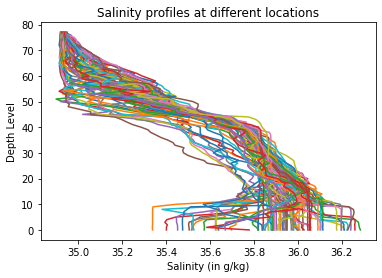

Text(0.5, 1.0, 'Temperature profiles at differen locations')

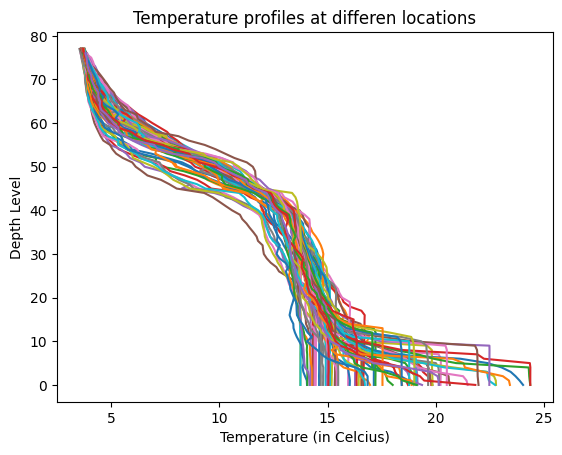

In [187]:
plt.plot(T,level); # The semi-colon prevents printing the line objects
plt.xlabel("Temperature (in Celcius)") # Takes a string as argument
plt.ylabel('Depth Level')
plt.title('Temperature profiles at differen locations')

Make more plots below:

Text(0.5, 1.0, 'Salinity profiles at different Location')

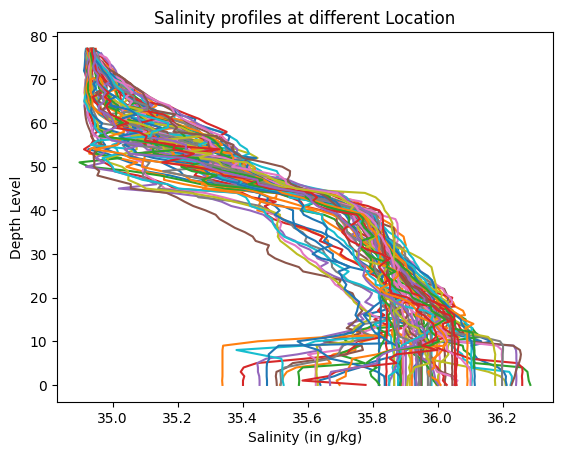

In [188]:
plt.plot(S,level);
plt.xlabel("Salinity (in g/kg)")
plt.ylabel('Depth Level')
plt.title('Salinity profiles at different Location')

Text(0.5, 1.0, 'Pressure at different Location')

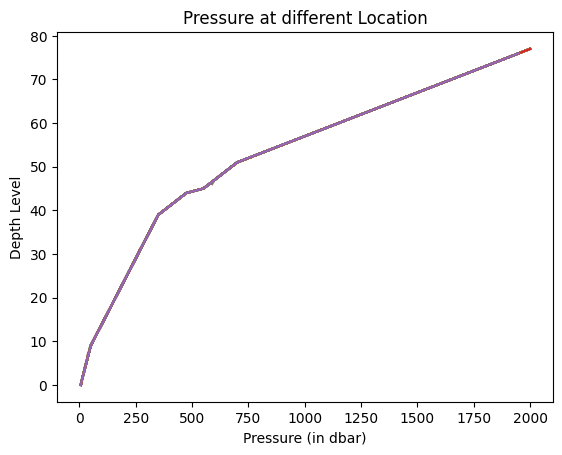

In [189]:
plt.plot(P,level);
plt.xlabel("Pressure (in dbar)")
plt.ylabel("Depth Level")
plt.title("Pressure at different Location")

Text(0.5, 1.0, 'Relative Density at different Location')

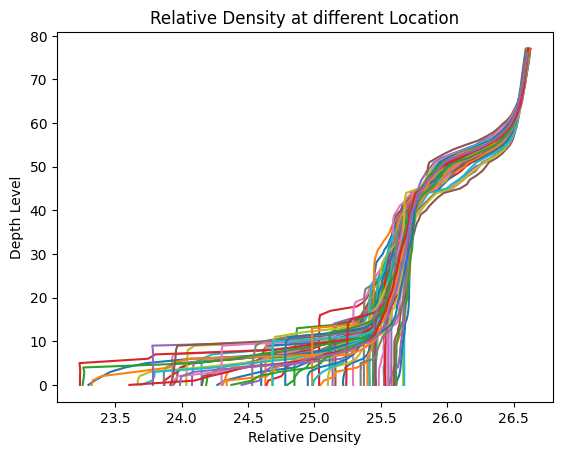

In [190]:
plt.plot(relative_density,level);
plt.xlabel("Relative Density")
plt.ylabel("Depth Level")
plt.title("Relative Density at different Location")

**Q5) Compute the mean and standard deviation of each of `T`, `S`, `P`, and `seawater_density` at each depth in `level`.**

Hint: You may want to read the documentation at [this link](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) and [this link](https://numpy.org/doc/stable/reference/generated/numpy.std.html).

Hint 2: You can check that you took the mean and standard deviations along the correct axes by checking the `shape` of your results.

Compute the means...

In [191]:
mean_T = np.mean(T,axis=0)
mean_S = np.mean(S,axis=0)
mean_P=np.mean(P,axis=0)
mean_seawater_density = np.mean(relative_density,axis=0)


... and the standard deviations.

In [192]:
stan_T = np.std(T, axis=0)
stan_S = np.std(S, axis=0)
stan_P = np.std(P,axis=0)
stan_seawater_densitiy = np.std(relative_density, axis=0)

Check that they have the same shape as your vertical level `lev` coordinate:

In [193]:
np.testing.assert_equal(mean_T.shape,lev.shape)

NameError: name 'lev' is not defined

In [ ]:
np.testing.assert_equal(stan_T.shape,lev.shape)

In [ ]:
np.testing.assert_equal(mean_S.shape,lev.shape)

In [ ]:
np.testing.assert_equal(stan_S.shape,lev.shape)

In [ ]:
np.testing.assert_equal(mean_P.shape,lev.shape)

In [ ]:
np.testing.assert_equal(stan_P.shape,lev.shape)

In [ ]:
np.testing.assert_equal(mean_seawater_density.shape,lev.shape)

In [ ]:
np.testing.assert_equal(stan_seawater_density.shape,lev.shape)

**SECOND ERROR**

While running np.testing.assert_equal, I kept getting a shape error.

Initial wrong attempt with T exemple:

**mean_T = np.mean(T, axis=0)**
**stan_T = np.std(T, axis=0)**

Test that failed:

**np.testing.assert_equal(mean_T.shape, lev.shape)**

The test failed for two reasons:
First of all I was using the variable name lev (because it was given in the exercise), but in our code the variable was actually defined as level.
Secondly, with axis=0 I was averaging along the depth dimension, which gave me one mean per profile (at a specific lat, lon, and date), instead of one mean per depth.

At first, I thought setting axis=0 would calculate the mean and standard deviation for each depth, because I imagined I was collapsing the data in the right direction. In reality, with axis=0 I was averaging down the rows (across depths), and I ended up with a vector the length of the number of profiles and not the number of depth levels. Moreover, since the shapes of my arrays did not match (the mean and standard deviation arrays were not consistent with the depth vector), the plotting functions such as plt.errorbar also failed, because they require arrays of compatible dimensions.

After some trial and error, I realized two things:
-the correct variable name was level, not lev;
-the correct axis is axis=1, so that the calculation is done across profiles (at different positions and dates) for each depth.

Correct solution:
**mean_T = np.mean(T, axis=1)**
**stan_T = np.std(T, axis=1)**

**np.testing.assert_equal(mean_T.shape, level.shape)**
**np.testing.assert_equal(stan_T.shape, level.shape)**

What really helped me understand the mistake was going back to the theory about NumPy axes and testing axis=0 and axis=1. By re-reading the documentation and re-running the code with both choices, I was finally able to grasp why I had confused rows and columns. At first, I was simply switching between axis=0 and axis=1, and while one option seemed to work, I could not clearly understand the logic behind it, which was confusing. To clarify this, I reviewed the theory again and also searched for additional explanations online (see this link https://medium.com/@weidagang/understanding-axes-in-numpy-8c889794e541). This helped me move beyond trial and error and actually understand how NumPy axes operate in practice. This axis-related error was probably also due to my difficulty in clearly visualizing the underlying structure of the arrays.
axis=0 reduces values down the rows (vertically,means across depths)
axis=1 reduces values across the columns (horizontally,means for each depth)


Another key step was using the .shape command (ex. mean_t.shape and level.shape). By printing and comparing the shapes of the arrays, I could clearly see the difference between the dimensions of my data and the level vector. This visualization made it much easier to understand the underlying structure of the arrays and to learn how the axes operate in practice.

Below, I have rewritten the correct code.



In [194]:
mean_T = np.mean(T,axis=1)
mean_S = np.mean(S,axis=1)
mean_P=np.mean(P,axis=1)
mean_seawater_density = np.mean(relative_density,axis=1)



In [195]:
stan_T = np.std(T, axis=1)
stan_S = np.std(S, axis=1)
stan_P = np.std(P,axis=1)
stan_seawater_density = np.std(relative_density, axis=1)

In [196]:
np.testing.assert_equal(mean_T.shape,level.shape)

In [197]:
np.testing.assert_equal(stan_T.shape,level.shape)

In [198]:
np.testing.assert_equal(mean_S.shape,level.shape)

In [199]:
np.testing.assert_equal(stan_S.shape,level.shape)

In [200]:
np.testing.assert_equal(mean_P.shape,level.shape)

In [201]:
np.testing.assert_equal(stan_P.shape,level.shape)

In [202]:
np.testing.assert_equal(mean_seawater_density.shape,level.shape)

In [203]:
np.testing.assert_equal(stan_seawater_density.shape,level.shape)

**Q6) Now make similar plots, but show only the mean `T`, `S`, `P`, and `seawater_density` at each depth. Show error bars on each plot using the standard deviations.**

Hint: If you are feeling adventurous, you can directly use the [`plt.errorbar`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.errorbar.html) function.

Hint 2: You should get plots similar to the one below

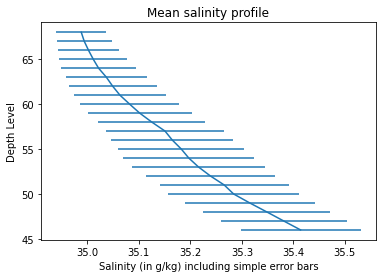

Text(0.5, 1.0, 'Mean Temperature profile')

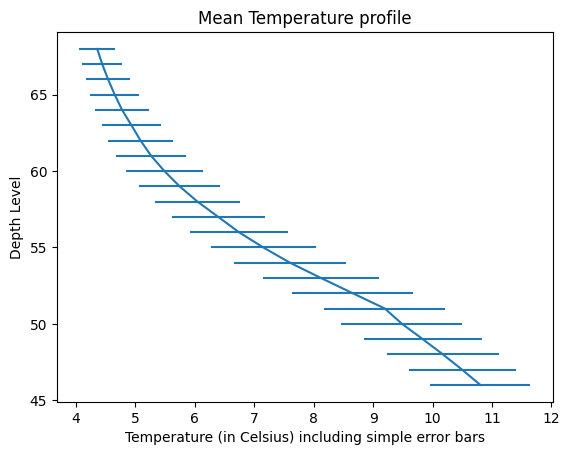

In [204]:
plt.errorbar(mean_T,level,xerr=stan_T)
plt.xlabel("Temperature (in Celsius) including simple error bars")
plt.ylabel("Depth Level")
plt.title("Mean Temperature profile")

Three more plots and we'll be all set! 🙂

Text(0.5, 1.0, 'Mean Salinity profile')

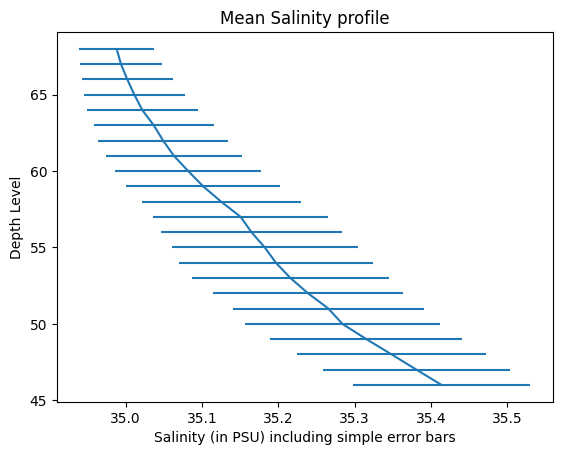

In [205]:
plt.errorbar(mean_S,level,xerr=stan_S)
plt.xlabel("Salinity (in PSU) including simple error bars")
plt.ylabel("Depth Level")
plt.title("Mean Salinity profile")

Text(0.5, 1.0, 'Mean Pressure profile')

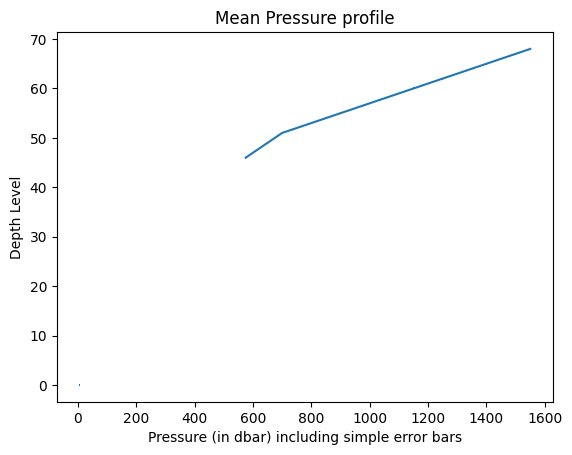

In [206]:
plt.errorbar(mean_P,level,xerr=stan_P)
plt.xlabel("Pressure (in dbar) including simple error bars")
plt.ylabel("Depth Level")
plt.title("Mean Pressure profile")

Text(0.5, 1.0, 'Mean Seawater Density profile')

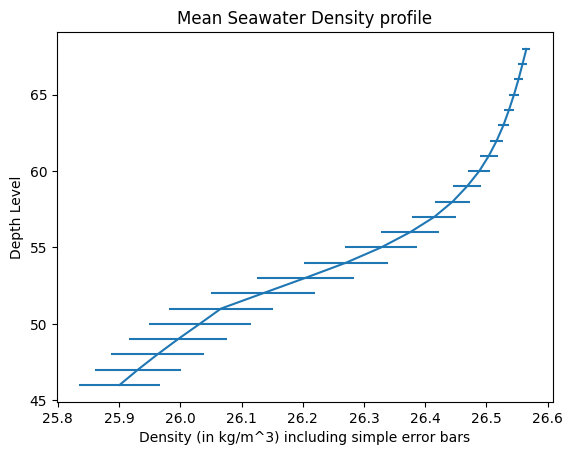

In [207]:
plt.errorbar(mean_seawater_density,level,xerr=stan_seawater_density)
plt.xlabel("Density (in kg/m^3) including simple error bars")
plt.ylabel("Depth Level")
plt.title("Mean Seawater Density profile")

**Q7) Account For Missing Data**

The profiles contain many missing values. These are indicated by the special “Not a Number” value, or `np.nan`.

When you take the mean or standard deviation of data with NaNs in it, the entire result becomes `NaN`. Instead, if you use the special functions `np.nanmean` and `np.nanstd`, you tell NumPy to ignore the NaNs.

Recalculate the means and standard deviations as in the previous sections using these functions and plot the results.

Hint: Links to the [`np.nanmean` documentation](https://numpy.org/doc/stable/reference/generated/numpy.nanmean.html) and the [`np.nanstd` documentation](https://numpy.org/doc/stable/reference/generated/numpy.nanstd.html).

Recalculate the means below ignoring the missing values. We trust that you can now come up with the full syntax yourself 😎

In [208]:
mean_t=np.nanmean(T, axis=1)
mean_p=np.nanmean(P,axis=1)
mean_s=np.nanmean(S,axis=1)
mean_SWD=np.nanmean(relative_density, axis=1)


Similarly, recalculate the standard deviations ignoring the missing values.

In [209]:
devi_t=np.nanstd(T,axis=1)
devi_p=np.nanstd(P,axis=1)
devi_s=np.nanstd(S,axis=1)
devi_SWD=np.nanstd(relative_density, axis=1)

**Q8) Create a scatter plot of the longitudinal (`lon`) and latitudinal (`lat`) coordinates of the ARGO floats.**

Again, we have not discussed it in the tutorial, but there is a really convenient scatter plot function called [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) provided by the Pyplot interface.

Bonus: Label your figure using `plt.xlabel`, `plt.ylabel`, and `plt.title`.

Bonus 2: Increase the fontsize of your labels by adding a `fontsize=` argument to the label functions.

Bonus 3: Make your scatter plot beautiful by changing the arguments of [`plt.scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) listed in the documentation, for example `s=`.

Text(0.5, 1.0, 'Mean Salinity profile')

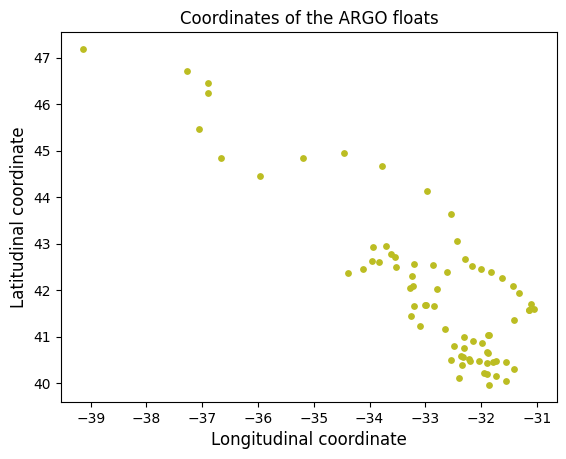

In [210]:

plt.scatter(lon,lat,s=15, c='#bcbd22')
plt.xlabel("Longitudinal coordinate", fontsize=12)
plt.ylabel("Latitudinal coordinate", fontsize=12)
plt.title("Coordinates of the ARGO floats") # Fancy bonuses
___ # More fancy bonuses